### ✅ 2.2 실습: 동기 vs 비동기 실행 시간 비교

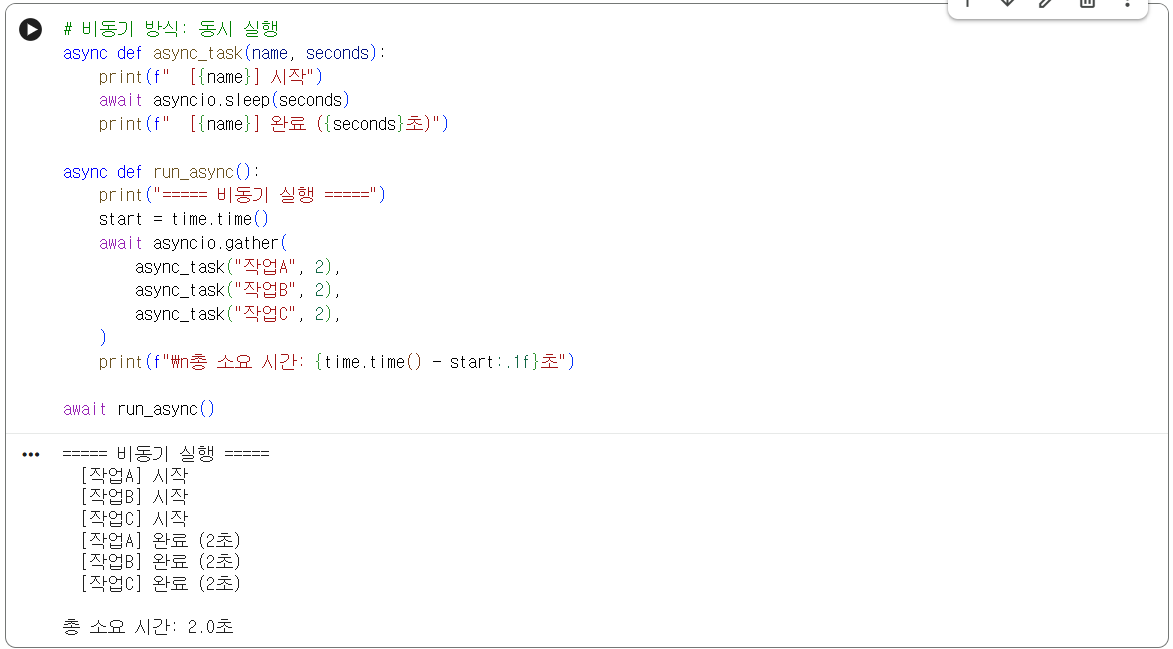

### ✅ 3.4 실험 3: blocking이 헬스체크까지 막는 현상

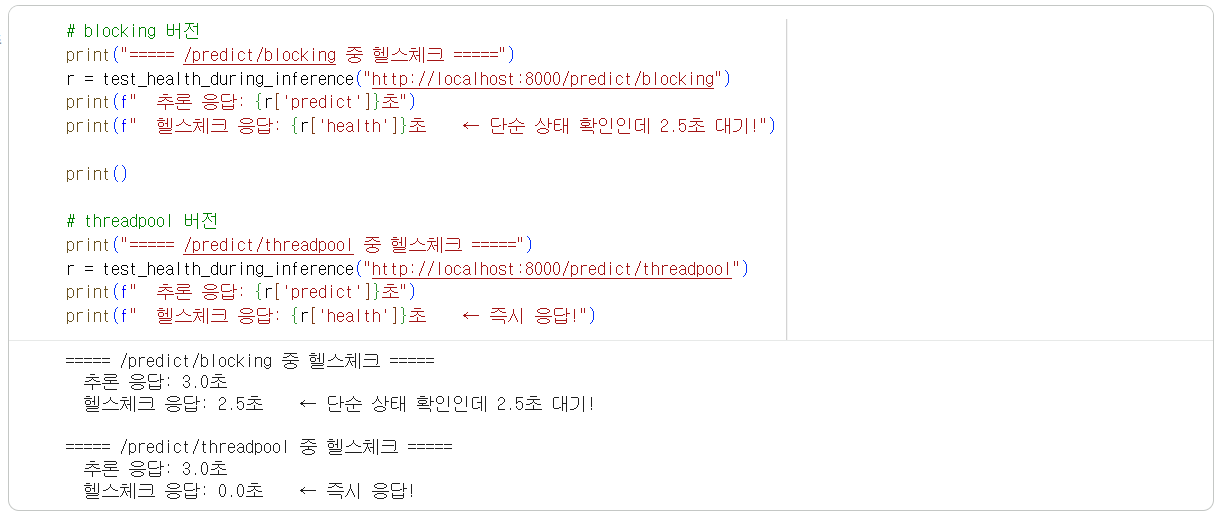



### ✅ 4.2 실습: 세 가지 버전 비교

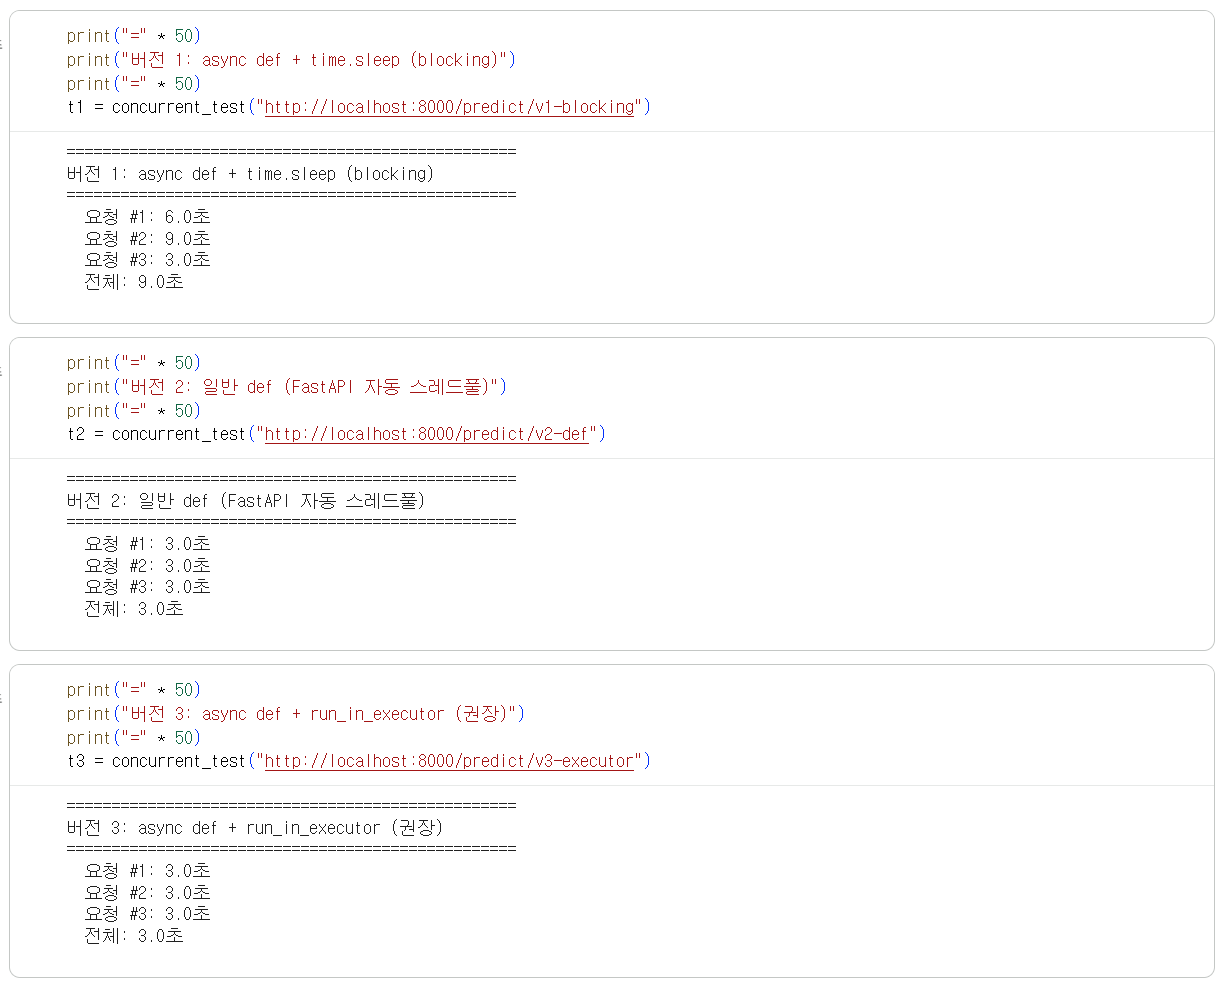

### ✅ 5.4 요청/응답 로깅 미들웨어

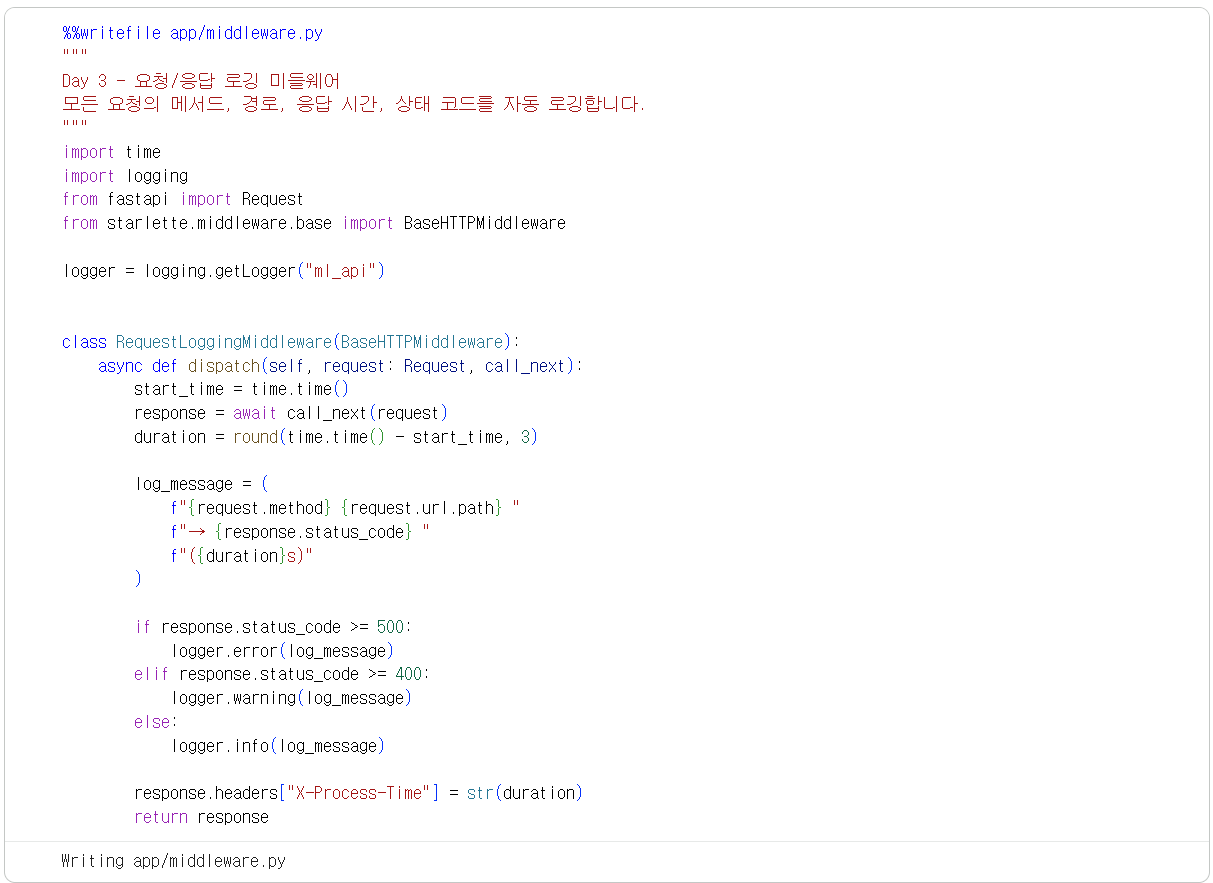

### ✅ 6.2 서버 실행 및 테스트
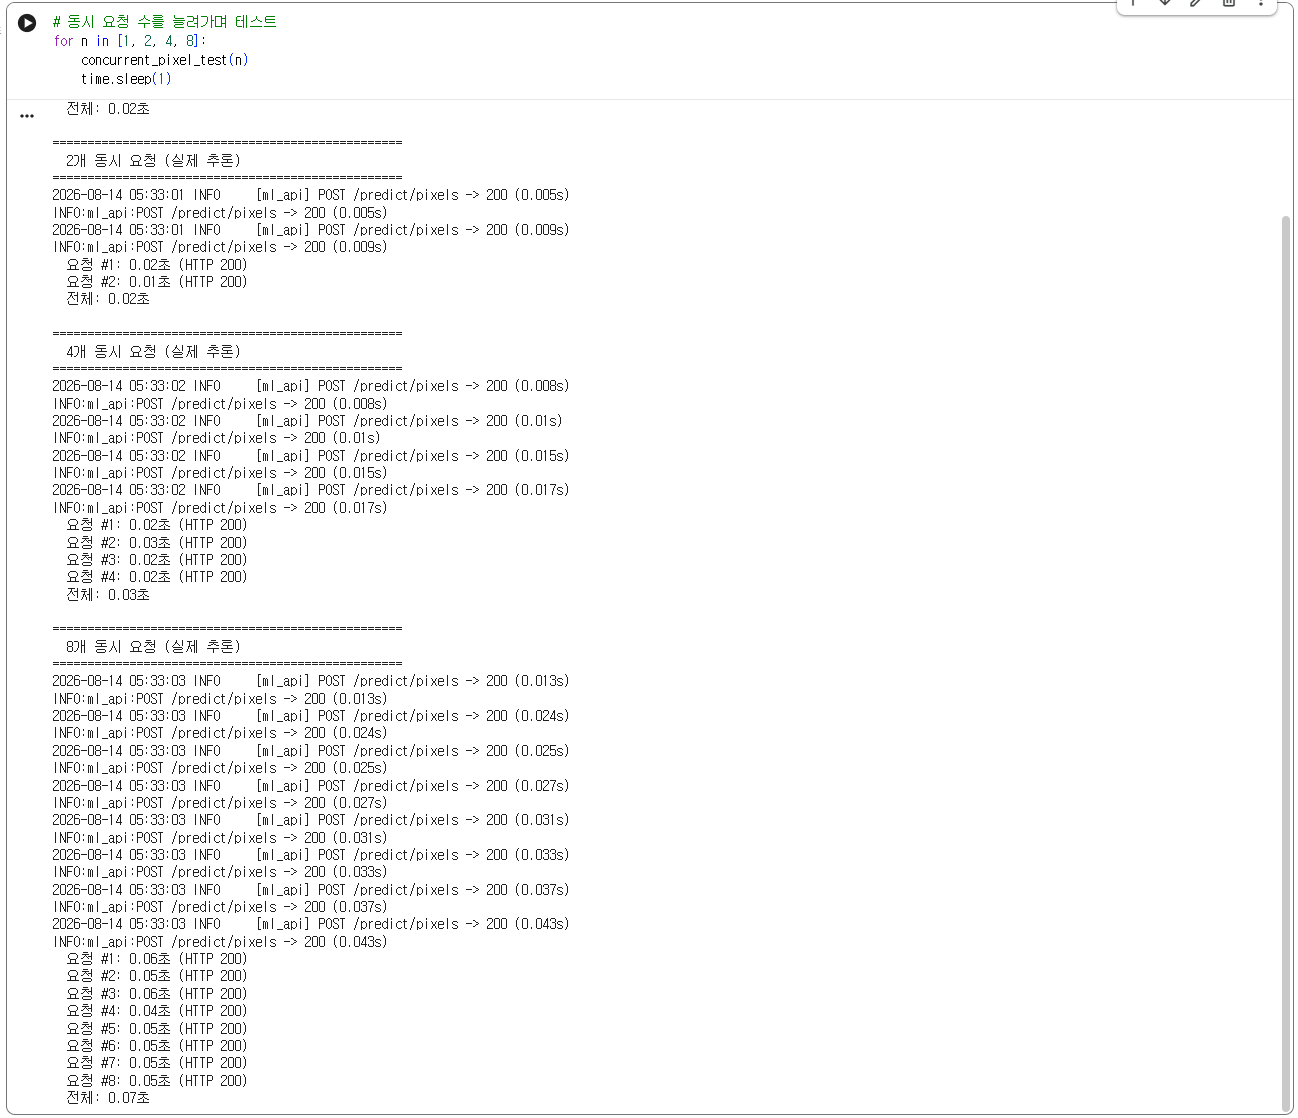
### ✅ 6.3 에러 핸들링 동작 확인
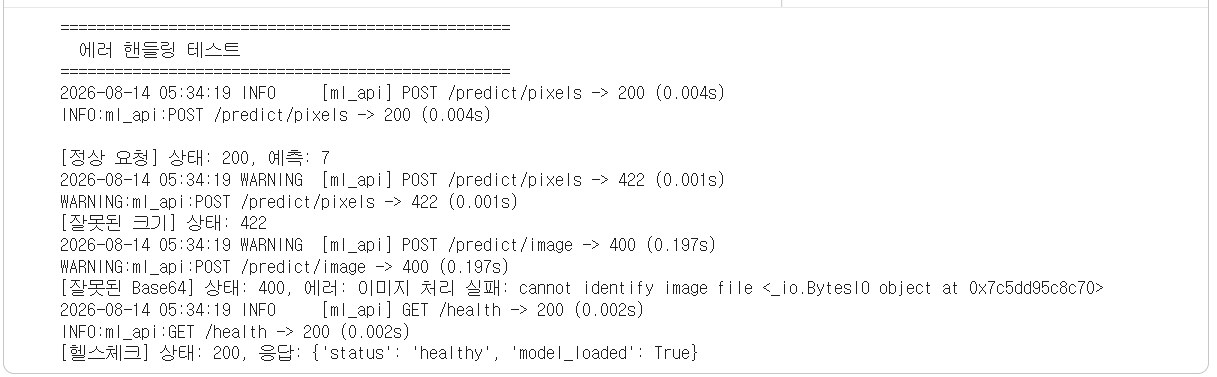



### ✅ 체크포인트 01

1. `time.sleep(3)`과 `await asyncio.sleep(3)`의 핵심 차이는 무엇입니까?
   - `time.sleep(3)`은 CPU를 3초간 점유하여 해당 스레드의 실행을 완전히 중단시킵니다. 이 시간 동안 다른 작업은 처리될 수 없습니다.
   - `await asyncio.sleep(3)`은 이벤트 루프에게 "3초 후에 나를 다시 깨워줘"라고 등록한 후, 제어권을 이벤트 루프에게 넘겨줍니다. 이벤트 루프는 이 3초 동안 다른 비동기 작업을 처리할 수 있습니다.
2. 모델 추론처럼 CPU를 계속 사용하는 작업에서 `async/await`만으로 동시 처리가 안 되는 이유는 무엇입니까?
   - `async/await`는 I/O 바운드(예: 네트워크 통신, 파일 읽기/쓰기) 작업과 같이 대기 시간이 긴 작업에서 다른 작업을 처리하여 효율을 높이는 방식입니다.
   - 모델 추론과 같은 CPU 바운드 작업은 CPU를 지속적으로 사용하여 계산을 수행합니다. 이 작업은 대기 시간이 발생하지 않으므로, `async/await`를 사용하더라도 이벤트 루프가 추론이 완료될 때까지 블로킹됩니다. 즉, 다른 작업을 처리할 틈이 없어 동시 처리 효과를 얻기 어렵습니다.

### ✅ 체크포인트 02

1. `async def` 안에서 `time.sleep(3)`을 호출하면 왜 다른 요청까지 지연됩니까?
   - `async def` 함수는 이벤트 루프에 의해 스케줄링됩니다. `time.sleep(3)`은 동기 함수이며, CPU를 점유하여 해당 스레드의 실행을 3초 동안 완전히 중단시킵니다. `async def` 함수 내에서 이 동기 블로킹 코드를 호출하면, 이벤트를 처리하는 단일 이벤트 루프 자체가 3초 동안 멈추게 됩니다. 결과적으로 이벤트 루프는 다른 비동기 작업을 처리할 수 없게 되어, 모든 대기 중인 요청이 함께 지연됩니다.
2. 일반 `def`로 선언된 엔드포인트는 FastAPI가 내부적으로 어떻게 처리합니까?
   - 일반 `def`로 선언된 엔드포인트는 FastAPI가 내부적으로 별도의 스레드풀(기본적으로 `ThreadPoolExecutor`)을 사용하여 실행합니다. 이는 동기 작업을 이벤트 루프 스레드 외부에서 처리하도록 하여, 동기 작업이 이벤트 루프를 블로킹하는 것을 방지합니다. 따라서 이벤트 루프는 다른 비동기 요청을 계속해서 처리할 수 있습니다.
3. blocking 추론 중 헬스체크까지 막히면 실무에서 어떤 문제가 발생할 수 있습니까?
   - 로드밸런서는 주기적으로 헬스체크 엔드포인트에 요청을 보내 서버의 상태를 확인합니다. 만약 blocking 추론 작업으로 인해 헬스체크 엔드포인트가 제때 응답하지 못하면, 로드밸런서는 해당 서버를 '다운' 상태로 판단하고 더 이상 트래픽을 보내지 않거나 심지어 서비스 풀에서 제거할 수 있습니다. 이는 서버가 실제로 살아있음에도 불구하고 서비스에서 제외되어 서비스 가용성에 심각한 문제를 초래할 수 있습니다.

### ✅ 체크포인트 03

1. `run_in_executor`가 이벤트 루프 블로킹을 방지하는 원리는 무엇입니까?
   - `run_in_executor`는 동기(blocking) 작업을 메인 이벤트 루프의 스레드에서 직접 실행하지 않고, 별도의 스레드 풀(Thread Pool)로 넘겨서 실행합니다. 이렇게 하면 메인 이벤트 루프는 동기 작업이 완료될 때까지 기다리지 않고, 다른 비동기 작업들을 계속 처리할 수 있게 됩니다. 동기 작업이 백그라운드 스레드에서 실행되는 동안, 이벤트 루프는 자유롭게 다른 I/O 바운드 작업이나 짧은 CPU 바운드 작업을 처리할 수 있습니다.
2. `run_in_executor`의 첫 번째 인자에 `None`을 넣으면 어떤 스레드풀이 사용됩니까?
   - `run_in_executor`의 첫 번째 인자에 `None`을 넣으면, `asyncio`의 기본 스레드 풀(Default Thread Pool)이 사용됩니다. 이 기본 스레드 풀은 일반적으로 `ThreadPoolExecutor` 인스턴스로, `asyncio`가 내부적으로 관리합니다.
3. 일반 `def`와 `async def + run_in_executor`의 핵심 차이는 무엇입니까?
   - **일반 `def` (동기 함수):** FastAPI는 동기 함수를 발견하면 자동으로 이를 `asyncio`의 기본 스레드 풀로 넘겨 실행합니다. 개발자가 명시적으로 `run_in_executor`를 호출할 필요가 없어 코드가 간결합니다. 하지만 이 경우 FastAPI가 관리하는 기본 스레드 풀을 사용하며, 이 스레드 풀의 크기나 동작 방식을 세밀하게 제어하기 어렵습니다.
   - **`async def + run_in_executor` (비동기 함수 내 동기 작업 위임):** 이 방식은 개발자가 명시적으로 비동기 함수를 선언하고, 그 안에서 `run_in_executor`를 사용하여 특정 동기 작업을 원하는 스레드 풀(기본 스레드 풀이든 커스텀 스레드 풀이든)로 위임합니다. 이는 스레드 풀의 크기나 목적을 개발자가 직접 제어하고 싶을 때 유용합니다.
4. GPU 추론 시 스레드풀 크기를 1~2로 제한하는 이유는 무엇입니까?
   - GPU는 대규모 병렬 처리에 최적화되어 있으므로, CPU 스레드를 늘려도 GPU 자체의 병렬 처리 능력은 크게 향상되지 않습니다. 오히려 많은 스레드를 사용하면 스레드 간의 컨텍스트 스위칭 오버헤드가 발생하고, 각 스레드가 GPU 리소스를 경쟁적으로 사용하여 병목 현상이나 GPU 메모리 부족(OOM) 오류가 발생할 위험이 커집니다. 따라서 효율적인 GPU 활용을 위해 스레드 풀 크기를 1~2개 정도로 작게 유지하는 것이 일반적입니다.

### ✅ 체크포인트 04

1. 글로벌 Exception Handler를 사용하면 어떤 반복을 줄일 수 있습니까?
   - 각 엔드포인트 함수마다 `try-except` 블록을 작성하여 예외를 처리하는 반복적인 작업을 줄일 수 있습니다. 하나의 중앙화된 핸들러로 모든 예외를 일관되게 처리할 수 있습니다.
2. 클라이언트에게 스택 트레이스를 노출하면 안 되는 이유는 무엇입니까?
   - **보안 위험:** 스택 트레이스에는 서버의 내부 구조, 파일 경로, 라이브러리 버전, 코드 조각 등 민감한 정보가 포함될 수 있습니다. 이를 노출하면 공격자가 서버의 취약점을 파악하는 데 활용될 수 있습니다.
   - **정보 과잉:** 클라이언트는 문제의 원인보다는 문제가 발생했다는 사실과 안전한 메시지를 필요로 합니다. 불필요한 기술적 세부 정보는 혼란을 줄 뿐입니다.
3. `logging` 모듈이 `print()`보다 나은 점은 무엇입니까?
   - **시간 정보 및 심각도:** `logging`은 메시지에 타임스탬프와 심각도(INFO, WARNING, ERROR 등)를 자동으로 추가하여 로그 분석을 용이하게 합니다.
   - **유연한 출력:** `logging`은 콘솔뿐만 아니라 파일, 네트워크, 외부 서비스 등으로 로그를 보낼 수 있는 다양한 핸들러를 제공합니다.
   - **모듈별 로깅:** 여러 모듈에서 별도의 로거를 설정하고 관리할 수 있어, 복잡한 애플리케이션의 로그를 체계적으로 분류하고 관리할 수 있습니다.
   - **로그 레벨 제어:** 설정된 로그 레벨에 따라 출력할 메시지의 심각도를 조절할 수 있어, 개발/운영 환경에 맞춰 필요한 로그만 확인할 수 있습니다.


### ✅ Day 3 최종 체크포인트


Q1. 동기 서버에서 3초 걸리는 추론을 3명이 동시에 요청하면 총 몇 초 걸립니까?
   - 동기 서버에서는 작업이 순차적으로 처리되므로, 각 추론이 3초씩 걸린다면 3명이 동시에 요청해도 총 **9초**가 걸립니다.

Q2. `time.sleep(3)`과 `await asyncio.sleep(3)`의 핵심 차이는?
   - `time.sleep(3)`은 CPU를 3초간 점유하여 해당 스레드의 실행을 완전히 중단시킵니다. 이 시간 동안 다른 작업을 처리할 수 없습니다.
   - `await asyncio.sleep(3)`은 이벤트 루프에게 "3초 후에 나를 다시 깨워줘"라고 등록한 후, 제어권을 이벤트 루프에게 넘겨줍니다. 이벤트 루프는 이 3초 동안 다른 비동기 작업을 처리할 수 있습니다.

Q3. `async def` 안에서 동기 블로킹 코드를 실행하면 왜 헬스체크까지 영향받습니까?
   - `async def` 함수 내에서 `time.sleep()`과 같은 동기 블로킹 코드를 실행하면, 해당 코드가 이벤트 루프 스레드에서 직접 실행됩니다. 단일 스레드 기반의 이벤트 루프는 이 코드가 완료될 때까지 완전히 멈추게 되어, 헬스체크와 같은 다른 비동기 요청도 처리할 수 없게 되기 때문입니다.

Q4. `run_in_executor`가 이벤트 루프 블로킹을 방지하는 원리는?
   - `run_in_executor`는 동기(blocking) 작업을 메인 이벤트 루프의 스레드에서 직접 실행하는 대신, 별도의 스레드 풀로 넘겨서 실행하도록 합니다. 이로써 메인 이벤트 루프는 동기 작업이 완료될 때까지 기다리지 않고 다른 비동기 작업들을 계속 처리할 수 있게 됩니다.

Q5. 글로벌 Exception Handler를 사용하는 이유는?
   - 각 엔드포인트 함수마다 `try-except` 블록을 작성하여 예외를 처리하는 반복적인 작업을 줄일 수 있습니다. 하나의 중앙화된 핸들러로 모든 예외를 일관되게 처리하여 코드의 간결성과 유지보수성을 높이고, 서버의 안정적인 동작을 보장합니다.
   
Q6. 클라이언트에게 스택 트레이스를 노출하면 안 되는 이유는?
   - 스택 트레이스에는 서버의 내부 구조, 파일 경로, 라이브러리 버전 등 민감한 정보가 포함될 수 있어 **보안 위험**이 있습니다. 또한 클라이언트에게는 불필요한 기술적 상세 정보로 혼란을 줄 수 있으므로, 상세 정보는 서버 로그에만 기록하고 클라이언트에게는 안전하고 일반적인 오류 메시지만 반환해야 합니다.
